In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

   Restaurant ID         Restaurant Name  Country Code              City  \
0        6317637        Le Petit Souffle           162       Makati City   
1        6304287        Izakaya Kikufuji           162       Makati City   
2        6300002  Heat - Edsa Shangri-La           162  Mandaluyong City   
3        6318506                    Ooma           162  Mandaluyong City   
4        6314302             Sambo Kojin           162  Mandaluyong City   

                                             Address  \
0  Third Floor, Century City Mall, Kalayaan Avenu...   
1  Little Tokyo, 2277 Chino Roces Avenue, Legaspi...   
2  Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...   
3  Third Floor, Mega Fashion Hall, SM Megamall, O...   
4  Third Floor, Mega Atrium, SM Megamall, Ortigas...   

                                     Locality  \
0   Century City Mall, Poblacion, Makati City   
1  Little Tokyo, Legaspi Village, Makati City   
2  Edsa Shangri-La, Ortigas, Mandaluyong City   
3      SM 

e:\Anaconda\Lib\site-packages\seaborn\categorical.py:379: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(-.5, n - .5, auto=None)
d:\Study\My space\Project\Data_Analysis\zomato\Zomato_Data_Analysis\EDA.ipynb:1687: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Rating color', data=ratings, palette=['white', 'red', 'orange', 'yellow', 'green', 'green'])
e:\Anaconda\Lib\site-packages\seaborn\categorical.py:379: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(-.5, n - .5, auto=None)
e:\Anaconda\Lib\site-packages\IPython\core\events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
e:\Anaconda\Lib\site-packages\I

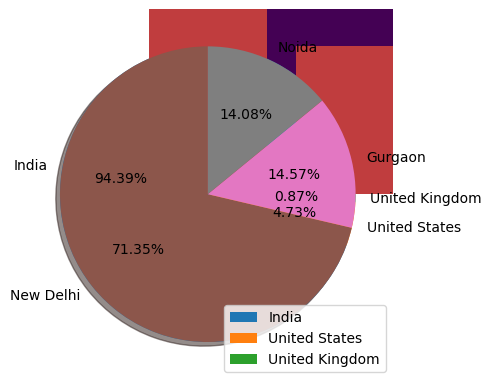

In [2]:
import importnb
with importnb.Notebook():
    import EDA as eda

In [3]:
df=eda.final_df
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes,Country
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Yes,No,No,No,3,4.8,Dark Green,Excellent,314,Phillipines
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Yes,No,No,No,3,4.5,Dark Green,Excellent,591,Phillipines
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Yes,No,No,No,4,4.4,Green,Very Good,270,Phillipines
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,No,No,No,No,4,4.9,Dark Green,Excellent,365,Phillipines
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Yes,No,No,No,4,4.8,Dark Green,Excellent,229,Phillipines


In [4]:
# Missing Data Analysis
df.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
Country                 0
dtype: int64

In [5]:
df['Cuisines']=df['Cuisines'].fillna(df['Cuisines'].mode()[0])

In [6]:
df.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                0
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
Country                 0
dtype: int64

In [7]:
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes', 'Country'],
      dtype='object')

In [8]:
#Dropping the duplicate restaurants from the dataset
print(df.duplicated(subset=['Restaurant Name']).sum())

2105


In [9]:
#Dropping the duplicate restaurants from the dataset
print(df.duplicated(subset=['Restaurant ID']).sum())

0


### Observation:
We can see in the above result of the duplicate finding there soo many restaurants with the same name but the they all have the different ids, and eventually may have different location, this means the other are the franchise outlets for example ccd and all. 

So, to findout the restaurant has the franchise outlet or not, creating the another feature n_outlet and is_chain.

In [10]:
df['n_outlets']=df.groupby("Restaurant Name")['Restaurant ID'].transform('count')
df['Is Chain']=df['n_outlets']>1

In [11]:
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes', 'Country', 'n_outlets', 'Is Chain'],
      dtype='object')

In [12]:
df_not_normalized=df.copy()
print(df_not_normalized[['Restaurant Name', 'Average Cost for two']])

               Restaurant Name  Average Cost for two
0             Le Petit Souffle                  1100
1             Izakaya Kikufuji                  1200
2       Heat - Edsa Shangri-La                  4000
3                         Ooma                  1500
4                  Sambo Kojin                  1500
...                        ...                   ...
9546              NamlÛ± Gurme                    80
9547             Ceviz AÛôacÛ±                   105
9548                     Huqqa                   170
9549              Aôôk Kahve                   120
9550  Walter's Coffee Roastery                    55

[9551 rows x 2 columns]


In [13]:
print(df.groupby(df['Country'])['Average Cost for two'].mean())

Country
Australia             24.083333
Brazil               134.666667
Canada                36.250000
India                623.370319
Indonesia         281190.476190
New Zealand           69.750000
Phillipines         1606.818182
Qatar                223.750000
Singapore            155.750000
South Africa         419.733333
Sri Lanka           2375.000000
Turkey                84.852941
UAE                  166.416667
United Kingdom        47.812500
United States         26.152074
Name: Average Cost for two, dtype: float64


In [14]:
#Normalizeing the average cost of two people so the comparison of accross the countries are valid
df['Average Cost for two']=df['Average Cost for two']/df.groupby(df['Country'])['Average Cost for two'].transform('mean')

In [15]:
df[['Country', 'Average Cost for two']]

,Country,Average Cost for two
0,Phillipines,0.684583
1,Phillipines,0.746818
2,Phillipines,2.489392
3,Phillipines,0.933522
4,Phillipines,0.933522
...,...,...
9546,Turkey,0.942808
9547,Turkey,1.237435
9548,Turkey,2.003466
9549,Turkey,1.414211


In [16]:
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes', 'Country', 'n_outlets', 'Is Chain'],
      dtype='object')

# Handling the outliers

In [17]:
# Using the interquartile range to identify the outliers in the dataset
Q1=df['Average Cost for two'].quantile(0.25)
Q3=df['Average Cost for two'].quantile(0.75)
IQR=Q3-Q1;
upperbound=Q3+1.5*IQR
lowerbound=Q1-1.5*IQR

outliers=df[(df['Average Cost for two']>upperbound) | (df['Average Cost for two']<lowerbound)]
print(outliers[['Country', 'Average Cost for two']])
print('Number of outliers:', outliers.shape[0])

           Country  Average Cost for two
2      Phillipines              2.489392
8      Phillipines              3.734088
40          Brazil              2.599010
59          Brazil              2.227723
66          Brazil              2.227723
...            ...                   ...
9433         Qatar              2.458101
9457  South Africa              3.668996
9464  South Africa              2.275254
9484  South Africa              7.647713
9526        Turkey              4.714038

[865 rows x 2 columns]
Number of outliers: 865


{'whiskers': [<matplotlib.lines.Line2D at 0x20e35377ed0>,
 'caps': [<matplotlib.lines.Line2D at 0x20e353a0190>,
 'boxes': [<matplotlib.lines.Line2D at 0x20e35377d90>],
 'medians': [<matplotlib.lines.Line2D at 0x20e353a0410>],
 'fliers': [<matplotlib.lines.Line2D at 0x20e353a0550>],
 'means': []}

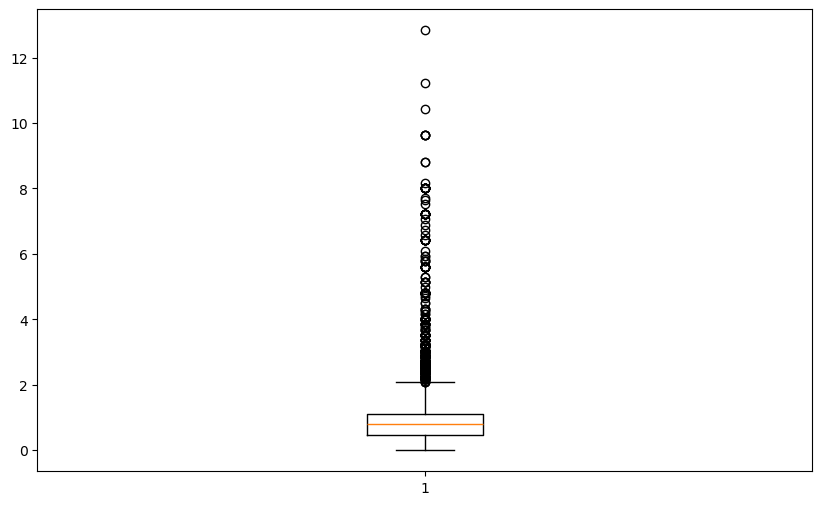

In [18]:
# Visualizing the outliers in the dataset using boxplot
plt.figure(figsize=(10, 6))
plt.boxplot(df['Average Cost for two'])

### Observation:
From the above result we can observe that there are so many outliers in the Average Cost for two, and from the result we have got from the IQR method also says that the outliers that we are getting are not because of Data entry or null values, it is because of the dataset it self, in dataset it contains the data for the different countries so that the currency of all the countries differ and the ppp(purchasing power parity) also differs in all the countries, so we are not able to remove this outliers niether can impute or manipulate them for the further analysis. So, in solution for this we have decided for further analysis we analysing the data for the 1 country India for now, means we doing the country specific analysis.

In [19]:
# Creating the dataframe which contain only the data of country India
df_india=df[df['Country']=='India'].copy()
# Use the untouched pre-normalization snapshot instead of a hardcoded constant,
# so India's cost is exactly the original raw INR value (no compounding float error,
# no stale constant that goes wrong when the row set changes upstream).
df_india['Average Cost for two']=df_not_normalized.loc[df_india.index, 'Average Cost for two']
df_india['Average Cost for two']=df_india['Average Cost for two'].round(0).astype(int)
print(df_india)
print(df_india.shape)
print(df_india[['Restaurant Name', 'Average Cost for two']])

      Restaurant ID                        Restaurant Name  Country Code  \
624         3400025                             Jahanpanah             1   
625         3400341                    Rangrezz Restaurant             1   
626         3400005                Time2Eat - Mama Chicken             1   
627         3400021  Chokho Jeeman Marwari Jain Bhojanalya             1   
628         3400017                         Pinch Of Spice             1   
...             ...                                    ...           ...   
9271        2800100                               D Cabana             1   
9272        2800418                               Kaloreez             1   
9273        2800881                                Plot 17             1   
9274        2800042                       Vista - The Park             1   
9275        2800019               Flying Spaghetti Monster             1   

       City                                            Address  \
624    Agra  E 23, Sh

In [20]:
df_india.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes', 'Country', 'n_outlets', 'Is Chain'],
      dtype='object')

In [21]:
#There are some of the columns that have 0 ratings in the aggregate rating but not because of the people have given them 0 ratings,
#it is because they haven't rated till now, we can see that in the Rating text, the have written it there "Not Rated"
df_india['Is Rated']=df_india['Aggregate rating']>0

In [22]:
df_india[df_india['Average Cost for two']==0]

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes,Country,n_outlets,Is Chain,Is Rated
634,3400073,The Latitude - Radisson Blu,1,Agra,"Radisson Blu, Taj East Gate Road, Tajganj, Agra","Radisson Blu, Tajganj","Radisson Blu, Tajganj, Agra",78.057044,27.163303,"North Indian, Chinese, Continental",...,No,1,3.9,Yellow,Good,103,India,1,False,True
637,3400346,Sheroes Hangout,1,Agra,"Opposite The Gateway Hotel, Fatehabad Road, Ta...",Tajganj,"Tajganj, Agra",78.040165,27.161850,"Cafe, North Indian, Chinese",...,No,1,4.9,Dark Green,Excellent,77,India,1,False,True
639,3400391,Chapter 1 Cafe,1,Agra,"1374 K/1375 K, 2nd floor, Dinesh Nagar, Fatehb...",Tajganj,"Tajganj, Agra",0.000000,0.000000,"Cafe, Italian, Mexican, North Indian, Continental",...,No,1,3.9,Yellow,Good,98,India,1,False,True
677,18317988,The BrewMaster,1,Allahabad,"Near Vishal Megamart, Civil Lines, Allahabad",Civil Lines,"Civil Lines, Allahabad",81.832796,25.451646,"North Indian, Chinese, Italian",...,No,1,3.3,Orange,Average,49,India,1,False,True
851,18279289,BMG - All Day Dining,1,Dehradun,"140 A, Rajpur Road, Jakhan, Dehradun",Jakhan,"Jakhan, Dehradun",78.068890,30.362686,"Chinese, North Indian, Fast Food",...,No,1,4.3,Green,Very Good,63,India,1,False,True
2364,2300497,Atmosphere Grill Cafe Sheesha,1,Kanpur,"8th Floor, J.S. Tower, 16/106 - Mall Road, Kan...",Mall Road,"Mall Road, Kanpur",80.354002,26.472001,"Indian, Chinese, Continental",...,No,1,3.6,Yellow,Good,34,India,1,False,True
2368,18312106,UrbanCrave,1,Kanpur,"14/125, The Mall, Mall Road, Colonelganj, Para...",Parade,"Parade, Kanpur",80.342796,26.474986,"Cafe, Continental, Desserts, Ice Cream, Italia...",...,No,1,3.9,Yellow,Good,127,India,1,False,True
9242,3900245,Deena Chat Bhandar,1,Varanasi,"D-47/184, Luxa Road, Dashaswmedh Road, Varanasi",Dashaswmedh Road,"Dashaswmedh Road, Varanasi",0.000000,0.000000,Street Food,...,No,1,3.8,Yellow,Good,78,India,1,False,True
9254,18246202,VNS Live Studio,1,Varanasi,"Hotel Varuna Ground Floor, 22 Gulab Bagh, Sigr...",Sigra,"Sigra, Varanasi",82.991694,25.318345,"Chinese, North Indian",...,No,1,3.5,Yellow,Good,109,India,1,False,True


### Obseravation:
We can see that, there are 9 rows which has average cost for two person is 0, which is not possible. So for the correct analysis we have to drop this rows.

In [23]:
df_india=df_india.drop(df_india[df_india['Average Cost for two']==0].index, axis=0)

In [24]:
df_india[df_india['Average Cost for two']==0]

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes,Country,n_outlets,Is Chain,Is Rated


In [25]:
# Now analsing the outlier with respect to the country India only again
# Using the interquartile range to identify the outliers in the dataset
Q1=df_india['Average Cost for two'].quantile(0.25)
Q3=df_india['Average Cost for two'].quantile(0.75)
IQR=Q3-Q1;
upperbound=Q3+1.5*IQR
lowerbound=Q1-1.5*IQR

outliers=df_india[(df_india['Average Cost for two']>upperbound) | (df_india['Average Cost for two']<lowerbound)]
print(outliers[['Country', 'Average Cost for two']])
print('Number of outliers:', outliers.shape[0])

     Country  Average Cost for two
629    India                  2000
630    India                  2500
631    India                  2500
633    India                  3600
638    India                  1500
...      ...                   ...
9223   India                  1500
9260   India                  1700
9262   India                  1600
9274   India                  1500
9275   India                  1400

[813 rows x 2 columns]
Number of outliers: 813


{'whiskers': [<matplotlib.lines.Line2D at 0x20e38f38050>,
 'caps': [<matplotlib.lines.Line2D at 0x20e38f382d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x20e353cbed0>],
 'medians': [<matplotlib.lines.Line2D at 0x20e38f38550>],
 'fliers': [<matplotlib.lines.Line2D at 0x20e38f38690>],
 'means': []}

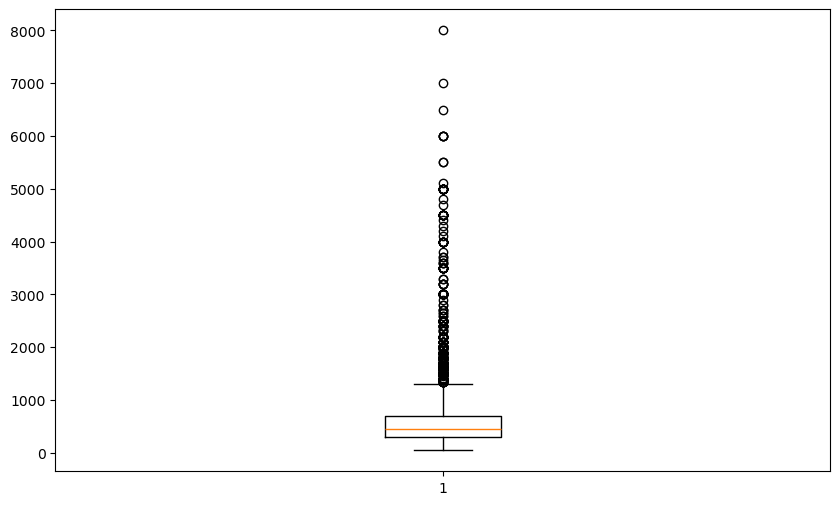

In [26]:
#Visualizing the outliers using boxplot
plt.figure(figsize=(10, 6))
plt.boxplot(df_india['Average Cost for two'])

### Observation:
After filtering the dataset for India only, we ran the IQR method on the 'Average Cost for two' column and found **813 outliers (9.41%)** of the Indian restaurants.

(Note: this count changed from the original 691/10.48% after the §0.2 dedupe fix — the old name-based dedupe had deleted ~2,048 valid chain-outlet restaurants, skewing the earlier IQR fence. 813 is the correct count on the full, honest 8,643-row dataset.)

These are not data entry errors — they are the premium/luxury segment, concentrated in metro cities: New Delhi (447), Gurgaon (157), Noida (60). Examples: Orient Express (Taj Palace Hotel), Bukhara / Tian - Asian Cuisine Studio (ITC Maurya), 1911 / Nostalgia at 1911 Brasserie (The Imperial).

Comparing **rated restaurants only** (`Aggregate rating > 0` — about 24.7% of restaurants are simply unrated, not rated 0, so they're excluded from this comparison): outliers average **3.75** vs **3.35** for all rated restaurants — confirming these are genuinely higher-rated, not data errors.

So, we have decided to keep this data as it is. Removing these outliers would remove the premium segment of restaurants and would bias our further analysis, as these are genuine data points and not errors.

## Final feature cleanup (§0.4)
- Drop columns that are constant or near-constant after the India filter: `Switch to order menu` (100% "No"), `Currency`, `Country`, `Country Code` (constants — everything is India/INR now), `Is delivering now` (34 Yes / 8,609 No — too rare to be a useful feature).
- Add `Is NCR` — a geography flag for the Delhi-NCR metro cluster (New Delhi, Gurgaon, Noida, Faridabad, Ghaziabad), since these 5 cities hold ~91% of the rows and everything else is thin, scattered coverage. `City` stays for reference; `Locality` remains the better column for fine-grained geography later.
- Document (not drop) the `Average Cost for two` / `Price range` redundancy — see the correlation check below.

In [27]:
# Dropping columns that are constant or near-constant once we're filtered to India only --
# they carry no information for further analysis.
dead_cols=['Switch to order menu','Currency','Country','Country Code','Is delivering now']
df_india=df_india.drop(columns=dead_cols)
df_india.columns

Index(['Restaurant ID', 'Restaurant Name', 'City', 'Address', 'Locality',
       'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Has Table booking', 'Has Online delivery',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes', 'n_outlets', 'Is Chain', 'Is Rated'],
      dtype='object')

In [28]:
# NCR (Delhi-National Capital Region) flag: these 5 cities hold ~91% of the rows,
# everything else is thin, scattered coverage -- useful for a clean geo split later.
ncr_cities=['New Delhi','Gurgaon','Noida','Faridabad','Ghaziabad']
df_india['Is NCR']=df_india['City'].isin(ncr_cities)
df_india['Is NCR'].value_counts()

Is NCR
True     7947
False     696
Name: count, dtype: int64

In [29]:
print('Average Cost for two vs Price range -- Pearson: %.3f, Spearman: %.3f' % (
    df_india['Average Cost for two'].corr(df_india['Price range']),
    df_india['Average Cost for two'].corr(df_india['Price range'], method='spearman')
))

Average Cost for two vs Price range -- Pearson: 0.838, Spearman: 0.911


### Observation:
`Average Cost for two` and `Price range` are Spearman ρ ≈ 0.91 correlated — `Price range` is effectively a binned version of cost. From here on they are treated as one signal, not two independent features, in correlation/statistical/modeling work.

In [30]:
# Saving the cleaned data in to a new csv file
os.makedirs('Output', exist_ok=True)
df_india.to_csv('Output/df_india_cleaned', index=False)